# 1. Introdução

## 1.1 Contexto

O Exame Nacional do Ensino Médio (ENEM), estabelecido em 1998 pelo Instituto Nacional de Estudos e Pesquisas Educacionais Anísio Teixeira (INEP), é hoje o principal instrumento de avaliação da educação básica brasileira e o maior acesso ao ensino superior no país, através do Sistema de Seleção Unificada (SISU). Com mais de oito milhões de inscritos por ano, a prova não só exerce seu papel original de diagnóstico, mas também se transformou em um excelente indicador da qualidade educacional no Brasil, revelando com exatidão as profundas assimetrias que marcam o sistema nacional de ensino.

 No estado de São Paulo, essa desigualdade ganha contornos ainda mais nítidos ao se observar seus 645 municípios. Em grandes cidades, existem escolas adequadamente equipadas e professores capacitados, e as famílias possuem maior renda e escolaridade, enquanto em municípios do interior e de regiões periféricas, muitas vezes se encontram falta de infraestrutura mínima, tanto no campo educacional quanto no social. Essa pluralidade faz com que o estado de São Paulo seja um “laboratório” propício para a análise das relações entre desempenho educacional e condições socioeconômicas locais. 

A literatura internacional já percebeu há muito tempo que o rendimento escolar não podia ser explicado apenas por fatores fundamentalmente educacionais. O título Equality of Educational Opportunity (COLEMAN et al. , 1966), conhecido como Coleman Report, se baseou em informações de mais de 600 mil estudantes americanos, e se tornou referência ao afirmar que fatores relacionados ao contexto familiar e socioeconômico dos alunos, como renda, escolaridade dos pais, e condições de moradia, têm impacto no desempenho acadêmico de maneira comparável ou até superior à da própria qualidade da escola frequentada. Coleman e colaboradores evidenciaram que a origem social do estudante condiciona profundamente suas trajetórias educacionais, destacando assim a necessidade de se analisar o desempenho escolar a partir de um olhar estrutural e territorial, e não apenas pedagógico.

Essa perspectiva é diretamente aplicável ao contexto brasileiro e, em particular, ao estado de São Paulo. Indicadores como o Índice de Desenvolvimento Humano Municipal (IDHM), a renda média per capita, o Índice de Gini, a taxa de analfabetismo, a escolaridade média da população adulta, a frequência escolar nos ensinos fundamental e médio, a probabilidade de pobreza entre adultos e crianças, e o acesso a serviços básicos como energia elétrica e água encanada nos trazem uma visão multidimensional das condições de vida nos municípios paulistas. Visto isso, a hipótese central deste trabalho é que esses indicadores socioeconômicos estão correlacionados com o desempenho médio dos municípios no ENEM, refletindo as desigualdades estruturais que atravessam o sistema educacional.

Modelo Formal
Para sistematizar essa hipótese, foi adotado um modelo de regressão múltipla em que a nota média municipal no ENEM é tratada como variável dependente, e os indicadores socioeconômicos municipais como variáveis explicativas. Formalmente:

 >Notai = β0 + β1(Escolaridadei) + β2(Rendai) + β3(Ginii) + β4(Analfabetismoi) + β5(Pobrezai) + β6(Infraestrutura) + β7(EscolaridadePais) + β8(FrequenciaFundamentali) + β9(SemEnergiai) + β10(AguaEncanadai) + β11(IDHi) + εi

onde i representa cada município do estado de São Paulo, β0 é o intercepto, os coeficientes β1 a β11 capturam o efeito marginal de cada indicador sobre a nota média municipal, e εi é o termo de erro. Este representa tudo aquilo que afeta a nota do município mas que não está sendo medido pelos seus indicadores. Com isso, espera-se que municípios com maiores índices de escolaridade, renda e acesso a serviços básicos apresentem notas médias significativamente superiores, ao passo que maiores índices de desigualdade (Gini), analfabetismo e pobreza sejam inversamente proporcionais ao desempenho no exame.


## 1.2 Hipótese

Existe uma disparidade significativa nas notas do ENEM entre diferentes municípios do estado de São Paulo, correlacionada com indicadores socioeconômicos locais.
Essa hipótese, fundamentada no viés analítico inaugurado pelo Coleman Report, orienta a investigação empírica desenvolvida nas seções seguintes, nas quais os dados são descritos, tratados e analisados com o objetivo de identificar padrões e correlações entre condições de vida e desempenho educacional no principal exame nacional de acesso ao ensino superior.

A literatura de economia da educação argumenta que o capital humano acumulado pelos indivíduos é influenciado pelo ambiente socioeconômico no qual estão inseridos. Municípios com maiores níveis de renda, escolaridade dos adultos e infraestrutura tendem a oferecer condições mais favoráveis ao aprendizado, resultando em melhor desempenho educacional, métrica que atualmente pode ser medida pelo desempenho médio dos jovens de um município no ENEM.

**Referência:**
COLEMAN, James S. et al. Equality of Educational Opportunity. Washington, D.C.: U.S. Department of Health, Education, and Welfare, 1966.


# 2. Dados

## 2.1 Descrição das bases de dados

3 bases de dados + Fontes

Microdados Enem 2025
https://www.gov.br/inep/pt-br/acesso-a-informacao/dados-abertos/microdados/enem

http://www.atlasbrasil.org.br/acervo/biblioteca

https://basedosdados.org/dataset/cbfc7253-089b-44e2-8825-755e1419efc8?table=ec5fb3d1-fa98-4ab3-8a02-4b9950048a83 

Coordenadas geográficas de SP
https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_municipais/municipio_2024/UFs/SP/SP_Municipios_2024.zip

Dicionário que explique cada feature

Dicionário para evitar nomes errados
Retirada de colunas irrelevantes
Outliers (média no agrupamento por munícipio)

Fontes:

## 2.2 Leitura e Merge das bases de dados

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

# 1. Carregar os dados processados do ENEM
df_enem = pd.read_csv('data/processed/enem_sp_completo_agrupado.csv')

# 2. Carregar o diretório de municípios (para garantir os nomes e siglas corretas)
df_dicionario_sp = pd.read_csv('data/raw/br_bd_diretorios_brasil_municipio.csv.gz')
df_dicionario_sp = df_dicionario_sp[df_dicionario_sp['sigla_uf'] == 'SP'][['id_municipio', 'nome']]

# 3. Carregar os dados de IDH/Infraestrutura
df_idh = pd.read_csv('data/raw/mundo_onu_adh_municipio.csv.gz')
# Filtrar apenas o ano mais recente (2010) para não duplicar linhas
df_idh = df_idh[df_idh['ano'] == 2010]

# Primeiro: Unimos o ENEM com o diretório para ter os nomes corretos das cidades
df = df_enem.merge(df_dicionario_sp, left_on='CO_MUNICIPIO_ESC', right_on='id_municipio')

# Segundo: Unimos com os dados de IDH/Infraestrutura
df = df.merge(df_idh, on='id_municipio')

# Visualizar o resultado
print(f"Total de municípios após o merge: {len(df)}")
municipios_sp = df['nome'].unique().tolist()
municipios_sp.sort()
print(f"Municípios de SP presentes no dataset: {municipios_sp}")
print(df.columns.tolist())

Total de municípios após o merge: 644
Municípios de SP presentes no dataset: ['Adamantina', 'Adolfo', 'Aguaí', 'Agudos', 'Alambari', 'Alfredo Marcondes', 'Altair', 'Altinópolis', 'Alto Alegre', 'Alumínio', 'Alvinlândia', 'Americana', 'Amparo', 'Américo Brasiliense', 'Américo de Campos', 'Analândia', 'Andradina', 'Angatuba', 'Anhembi', 'Anhumas', 'Aparecida', "Aparecida d'Oeste", 'Apiaí', 'Aramina', 'Arandu', 'Arapeí', 'Araraquara', 'Araras', 'Araçariguama', 'Araçatuba', 'Araçoiaba da Serra', 'Arco-Íris', 'Arealva', 'Areias', 'Areiópolis', 'Ariranha', 'Artur Nogueira', 'Arujá', 'Aspásia', 'Assis', 'Atibaia', 'Auriflama', 'Avanhandava', 'Avaré', 'Avaí', 'Bady Bassitt', 'Balbinos', 'Bananal', 'Barbosa', 'Bariri', 'Barra Bonita', 'Barra do Chapéu', 'Barra do Turvo', 'Barretos', 'Barrinha', 'Barueri', 'Barão de Antonina', 'Bastos', 'Batatais', 'Bauru', 'Bebedouro', 'Bento de Abreu', 'Bernardino de Campos', 'Bertioga', 'Bilac', 'Birigui', 'Biritiba-Mirim', 'Boa Esperança do Sul', 'Bocaina', 

## 2.3 Feature engineering

In [2]:
# Criação da nota_final juntando as notas por área do conhecimento
df['nota_final'] = (df["NU_NOTA_CN"]+df['NU_NOTA_CH']+ df['NU_NOTA_LC'] +df['NU_NOTA_MT']+ df['NU_NOTA_REDACAO'])/5
municipios = ['Ferraz de Vasconcelos', 'Indaiatuba', 'Jundiaí', 'Itaquaquecetuba', 'São Paulo', 'Poá', 'Osasco','Guarulhos','São Bernardo' ]
for i in municipios:
    df1 = df[df['nome']== i]
    colunas = ["nome",'nota_final', "idhm"]
    print(df1[colunas])
    print("---"*30)

# Média do Brasil é 546

                      nome  nota_final   idhm
180  Ferraz de Vasconcelos  520.019765  0.738
------------------------------------------------------------------------------------------
           nome  nota_final   idhm
235  Indaiatuba  559.793855  0.788
------------------------------------------------------------------------------------------
        nome  nota_final   idhm
293  Jundiaí  575.006047  0.822
------------------------------------------------------------------------------------------
                nome  nota_final   idhm
264  Itaquaquecetuba  515.023617  0.714
------------------------------------------------------------------------------------------
          nome  nota_final   idhm
561  São Paulo  558.513053  0.805
------------------------------------------------------------------------------------------
    nome  nota_final   idhm
444  Poá  523.364329  0.771
------------------------------------------------------------------------------------------
       nome  nota_final 

In [3]:
# Seleção das colunas de interesse:
colunas = ['nome', 'nota_final', 'id_municipio', 'idhm', "idhm_e", "idhm_l", "idhm_r", "indice_frequencia_escolar", "indice_escolaridade","taxa_sem_energia_eletrica", "taxa_agua_encanada", 'taxa_atividade_15_17', 'renda_media_ocupados', 'renda_pc', 'renda_pc_pobreza_extrema', 'prop_vulner_pobreza_criancas', 'prop_pobreza', 'indice_gini', 'prop_pobreza_criancas','taxa_freq_fundamental_15_17', 'taxa_analfabetismo_15_a_17']
df_final = df[colunas].set_index(['id_municipio', 'nome'])
print(df_final.head())

                               nota_final   idhm  idhm_e  idhm_l  idhm_r  \
id_municipio nome                                                          
3500105      Adamantina        571.076814  0.790   0.750   0.852   0.772   
3500204      Adolfo            506.822308  0.730   0.648   0.844   0.710   
3500303      Aguaí             509.269302  0.715   0.606   0.858   0.703   
3500402      Águas da Prata    552.307500  0.781   0.716   0.886   0.750   
3500501      Águas de Lindóia  556.668736  0.745   0.675   0.846   0.725   

                               indice_frequencia_escolar  indice_escolaridade  \
id_municipio nome                                                               
3500105      Adamantina                            0.833                0.608   
3500204      Adolfo                                0.788                0.439   
3500303      Aguaí                                 0.690                0.467   
3500402      Águas da Prata                        0.814      

## 2.4 Limpeza de dados nulos

In [4]:
# Visualização de valores nulos
print(df_final.isna().sum())
# Qual o nome do munícipio com nota final faltando?
municipios_faltando_nota = df_final[df_final['nota_final'].isna()].index.get_level_values('nome').unique().tolist()
print(f"Municípios com nota final faltando: {municipios_faltando_nota}")
df_final.dropna(subset=['nota_final'], inplace=True)
print(df_final.isna().sum())
# Quantidade de colunas agora:
print(f"Quantidade de linhas após remover linhas com nota final faltando: {df_final.shape[0]}")

nota_final                      1
idhm                            0
idhm_e                          0
idhm_l                          0
idhm_r                          0
indice_frequencia_escolar       0
indice_escolaridade             0
taxa_sem_energia_eletrica       0
taxa_agua_encanada              0
taxa_atividade_15_17            0
renda_media_ocupados            0
renda_pc                        0
renda_pc_pobreza_extrema        0
prop_vulner_pobreza_criancas    0
prop_pobreza                    0
indice_gini                     0
prop_pobreza_criancas           0
taxa_freq_fundamental_15_17     0
taxa_analfabetismo_15_a_17      0
dtype: int64
Municípios com nota final faltando: ['Arco-Íris']
nota_final                      0
idhm                            0
idhm_e                          0
idhm_l                          0
idhm_r                          0
indice_frequencia_escolar       0
indice_escolaridade             0
taxa_sem_energia_eletrica       0
taxa_agua_encanada 

In [5]:
# Verificar a presença de outliers nas notas do ENEM pelo método do IQR:
Q1 = df_final['nota_final'].quantile(0.25)
Q3 = df_final['nota_final'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
outliers = df_final[(df_final['nota_final'] < limite_inferior) | (df_final['nota_final'] > limite_superior)]
print(f"Municípios considerados outliers: {outliers.index.get_level_values('nome').tolist()}")
# Notas consideradas outliers:
print(outliers['nota_final'].tolist())

Municípios considerados outliers: ['Álvaro de Carvalho', 'Cândido Rodrigues', 'Inúbia Paulista']
[635.6600000000001, 424.2299999999999, 622.1700000000001]


In [ ]:
# Verificar a presença de outliers nas variáveis socioeconômicas pelo mesmo método IQR:
def analisar_outliers(df):
    colunas = [
        'idhm', 'idhm_e', 'idhm_l', 'idhm_r',
        'indice_frequencia_escolar', 'indice_escolaridade',
        'taxa_sem_energia_eletrica', 'taxa_agua_encanada',
        'taxa_atividade_15_17', 'renda_media_ocupados',
        'renda_pc', 'renda_pc_pobreza_extrema',
        'prop_vulner_pobreza_criancas', 'prop_pobreza',
        'indice_gini', 'prop_pobreza_criancas',
        'taxa_freq_fundamental_15_17', 'taxa_analfabetismo_15_a_17'
    ]

    df_analise = df.copy()

    for coluna in colunas:
        serie = df_analise[coluna].dropna()

        q1 = serie.quantile(0.25)
        q3 = serie.quantile(0.75)
        iqr = q3 - q1

        lim_inf = q1 - 1.5 * iqr
        lim_sup = q3 + 1.5 * iqr

        mask = (df_analise[coluna] < lim_inf) | (df_analise[coluna] > lim_sup)
        outliers_df = df_analise[mask]

        print(f"\n===== {coluna} =====")
        print(f"Quantidade de outliers: {len(outliers_df)}")

        if len(outliers_df) > 0:
            print(f"Municípios: {outliers_df.index.get_level_values('nome').tolist()}")
            print(f"Valores:    {outliers_df[coluna].tolist()}")
        else:
            print("Nenhum outlier encontrado.")

# Chama a função
analisar_outliers(df_final)


===== idhm =====
Quantidade de outliers: 7
Municípios: ['Águas de São Pedro', 'Barra do Turvo', 'Natividade da Serra', 'Nova Campina', 'Ribeirão Branco', 'Santos', 'São Caetano do Sul']
Valores:    [0.854, 0.641, 0.655, 0.651, 0.639, 0.84, 0.862]

===== idhm_e =====
Quantidade de outliers: 8
Municípios: ['Águas de São Pedro', 'Balbinos', 'Barra do Turvo', 'Iaras', 'Natividade da Serra', 'Quadra', 'Santos', 'São Caetano do Sul']
Valores:    [0.825, 0.537, 0.532, 0.543, 0.52, 0.541, 0.807, 0.811]

===== idhm_l =====
Quantidade de outliers: 0
Nenhum outlier encontrado.

===== idhm_r =====
Quantidade de outliers: 19
Municípios: ['Águas de São Pedro', 'Barra do Chapéu', 'Bom Sucesso de Itararé', 'Campinas', 'Holambra', 'Itapirapuã Paulista', 'Jundiaí', 'Nova Campina', 'Ribeirão Branco', 'Ribeirão Preto', 'Santa Cruz da Conceição', 'Santana de Parnaíba', 'Santo André', 'Santos', 'São Caetano do Sul', 'São Paulo', 'Taquarivaí', 'Valinhos', 'Vinhedo']
Valores:    [0.849, 0.617, 0.605, 0.829, 

Como no caso dos dados socioeconômicos dos municípios os outliers podem representar a realidade excessivamente melhor/pior dos parâmetros estudados, optou-se por não fazer a winsorização desses dados, de modo a mantê-los normalmente no dataframe

In [7]:
# Winsorização(tratamento que restringe os outliers aos limites definidos anteriormente):
df_final['nota_final'] = df_final['nota_final'].clip(lower=limite_inferior, upper=limite_superior)
# Comparar as notas antes e depois da winsorização nos múnicipios considerados outliers:
df_outliers = df_final.loc[outliers.index]
print(df_outliers[['nota_final']])

                                 nota_final
id_municipio nome                          
3501400      Álvaro de Carvalho  613.724199
3510104      Cândido Rodrigues   429.643414
3520806      Inúbia Paulista     613.724199


## 2.5 Estatística Descritiva

In [8]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 643 entries, (np.int64(3500105), 'Adamantina') to (np.int64(3557303), 'Estiva Gerbi')
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   nota_final                    643 non-null    float64
 1   idhm                          643 non-null    float64
 2   idhm_e                        643 non-null    float64
 3   idhm_l                        643 non-null    float64
 4   idhm_r                        643 non-null    float64
 5   indice_frequencia_escolar     643 non-null    float64
 6   indice_escolaridade           643 non-null    float64
 7   taxa_sem_energia_eletrica     643 non-null    float64
 8   taxa_agua_encanada            643 non-null    float64
 9   taxa_atividade_15_17          643 non-null    float64
 10  renda_media_ocupados          643 non-null    float64
 11  renda_pc                      643 non-null    float64
 12  

In [9]:
df_final.describe()

,nota_final,idhm,idhm_e,idhm_l,idhm_r,indice_frequencia_escolar,indice_escolaridade,taxa_sem_energia_eletrica,taxa_agua_encanada,taxa_atividade_15_17,renda_media_ocupados,renda_pc,renda_pc_pobreza_extrema,prop_vulner_pobreza_criancas,prop_pobreza,indice_gini,prop_pobreza_criancas,taxa_freq_fundamental_15_17,taxa_analfabetismo_15_a_17
count,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000
mean,520.468693,0.739622,0.676383,0.836068,0.716649,0.780037,0.512703,0.243904,96.561711,34.555754,1110.343904,714.590575,33.726656,34.769409,5.979393,0.449378,11.421182,14.571602,1.113002
std,31.870569,0.032475,0.048425,0.021939,0.040227,0.049624,0.079122,0.896514,5.100037,8.770022,281.162669,197.341499,12.378011,11.939997,4.674941,0.055845,7.420537,5.835451,0.638189
min,429.643414,0.639000,0.520000,0.775000,0.592000,0.632000,0.259000,0.000000,59.860000,7.070000,584.650000,318.440000,0.000000,7.450000,0.420000,0.330000,0.670000,0.000000,0.000000
25%,498.673709,0.719000,0.644000,0.818000,0.691000,0.748000,0.457000,0.000000,96.325000,29.115000,933.285000,588.930000,27.220000,26.405000,3.275000,0.410000,6.890000,10.440000,0.750000
50%,519.532500,0.738000,0.678000,0.837000,0.716000,0.776000,0.502000,0.060000,98.500000,33.880000,1064.240000,686.890000,34.710000,33.250000,4.750000,0.450000,9.650000,14.050000,1.060000
75%,544.693905,0.761000,0.709000,0.853000,0.740000,0.812000,0.566500,0.210000,99.310000,39.585000,1218.915000,799.335000,40.570000,41.040000,7.035000,0.485000,13.400000,17.765000,1.400000
max,613.724199,0.862000,0.825000,0.890000,0.891000,0.962000,0.762000,14.960000,100.000000,72.000000,3177.260000,2043.740000,68.890000,76.920000,35.110000,0.670000,49.400000,43.480000,6.320000


In [10]:
df_final.shape

(643, 19)

# 3. Resultados

## 3.1 Calculo das correlações e métodos

 Para investigar a influência dos indicadores socioeconômicos e de infraestrutura sobre o desempenho educacional no Estado de São Paulo, utilizou-se a análise de correlação estatística. O objetivo central é coletar subsídios empíricos para validar ou refutar a hipótese de que a vulnerabilidade social e a distribuição de renda nos municípios paulistas exercem impacto no resultado médio obtido pelos candidatos no Exame Nacional do Ensino Médio (ENEM).  

 A análise foi estruturada a partir do cruzamento da variável dependente (nota_final) com o vetor de variáveis explicativas socioeconômicas selecionadas anteriormente. A fim de garantir a amplitude metodológica da investigação nesta etapa inicial, aplicaram-se dois coeficientes de correlação distintos:
Coeficiente de Correlação de Pearson ($r$)
Trata-se de uma métrica paramétrica que quantifica a força e a direção de uma associação linear entre duas variáveis contínuas. Matematicamente, baseia-se na covariância das variáveis normalizada pelo produto de seus respectivos desvios padrão:
$$r = \frac{\text{cov}(X, Y)}{\sigma_X \sigma_Y}

$$Coeficiente de Correlação de postos de Spearman ($\rho$)
Trata-se de um teste não paramétrico que avalia a existência de uma relação monotônica entre as variáveis utilizando a classificação por postos (ranks) em vez dos valores brutos dos dados:
$$\rho = 1 - \frac{6 \sum d_i^2}{n(n^2 - 1)}$$
O bloco de código a seguir executa ambos os algoritmos sobre o conjunto de dados unificado (df_final), isolando e ordenando as dez variáveis que apresentam os maiores coeficientes de associação absoluta com a nota média dos municípios.

In [11]:
variavel_de_notas = 'nota_final'
# Calculamos a correlação pelos metodos de spearman e pearson para descobrirmos as variaveis que mais se correlacionam com a nota a fim de compará-las
spearman = df_final.corr(method='spearman')[variavel_de_notas].abs()
pearson = df_final.corr(method='pearson')[variavel_de_notas].abs()
# Visualização dos resultados do método spearman
print('Váriaveis que mais se relacionam com a nota pelo método Spearman')
maiores_spearman = spearman.drop(variavel_de_notas).sort_values(ascending=False).head(10)
print(maiores_spearman)
# Visualização dos resultados do método pearson
print('Váriaveis que mais se relacionam com a nota pelo método Pearson')
maiores_pearson = pearson.drop(variavel_de_notas).sort_values(ascending=False).head(10)
print(maiores_pearson)

Váriaveis que mais se relacionam com a nota pelo método Spearman
renda_pc                        0.598841
idhm_r                          0.598327
idhm                            0.573366
renda_media_ocupados            0.567323
indice_escolaridade             0.533906
prop_vulner_pobreza_criancas    0.442633
idhm_e                          0.433525
idhm_l                          0.419872
prop_pobreza                    0.338868
prop_pobreza_criancas           0.324932
Name: nota_final, dtype: float64
Váriaveis que mais se relacionam com a nota pelo método Pearson
idhm_r                          0.579019
renda_pc                        0.562714
idhm                            0.558804
indice_escolaridade             0.533549
renda_media_ocupados            0.522848
idhm_e                          0.419176
prop_vulner_pobreza_criancas    0.417455
idhm_l                          0.417371
prop_pobreza_criancas           0.318814
prop_pobreza                    0.311123
Name: nota_final, 

### 3.1.2 Qual correlação usar?

Enquanto a correlação de Pearson mede associação linear e é mais sensível a outliers, o método de Spearman mede associação monotônica baseada nos rankings, e no geral é mais robusta. Como uma simplificação, fará-se a escolha definitiva entre os coeficientes de Pearson e Spearman a depender da aderência dos dados à distribuição normal. Enquanto o método de Pearson pressupõe que as variáveis sigam uma distribuição normal, o método de Spearman, por ser não-paramétrico, prescinde dessa suposição.Para fundamentar essa decisão, aplicou-se o Teste de Shapiro-Wilk sobre a variável dependente (nota_final) e o vetor de variáveis explicativas socioeconômicas, utilizando o pacote estatístico scipy.stats do Python.
O Shapiro-Wilk estrutura-se como um teste de hipóteses convencional, definido por:

Hipótese Nula ($H_0$): Os dados seguem uma distribuição normal.

Hipótese Alternativa ($H_1$): Os dados não seguem uma distribuição normal.

O critério de decisão pauta-se no nível de significância ($p\text{-valor}$). Adotando-se o limite padrão de $5\%$ ($\alpha = 0.05$), a rejeição da hipótese nula ($p < 0.05$) constata matematicamente a não-normalidade da distribuição, indicando que a abordagem de Spearman é a mais adequada para a análise.

A seleção deste teste justifica-se por sua ampla consolidação na literatura estatística e por sua viabilidade computacional no ecossistema de análise de dados do Python. Dado que a amostra deste estudo é composta pelos $645$ municípios do Estado de São Paulo, o teste de Shapiro-Wilk apresenta alto poder estatístico para identificar desvios de normalidade sem a necessidade de recorrer a métodos alternativos mais complexos e restritivos, como o de Kolmogorov-Smirnov.

In [12]:
from scipy import stats

stat_nota, p_nota = stats.shapiro(df_final['nota_final'])
print(f'Nota final - valor-p: {p_nota:.5f}')
nota_eh_normal = p_nota > 0.05

if nota_eh_normal:
    print("A variável 'nota_final' tem distribuição normal, portanto, o melhor método de correlação seria o pearson")
else:
    print("A variável 'nota_final' não tem distribuição normal, portanto, o melhor método de correlação seria o de spearman")

# Testando a normalidade das outras variáveis
variaveis_para_testar = [
    'idhm_r', 'renda_pc', 'indice_escolaridade', 'prop_pobreza',
    'prop_pobreza_criancas', 'indice_frequencia_escolar',
    'taxa_analfabetismo_15_a_17', 'taxa_sem_energia_eletrica',
    'renda_pc_pobreza_extrema'
]

print(f"\n--- ANÁLISE DE NORMALIDADE (p-valor da Nota Final: {p_nota:.5f}) ---\n")

for var in variaveis_para_testar:
    _, p_var = stats.shapiro(df_final[var])

    print(f"Variável: '{var}' | valor-p: {p_var:.5f}")

    if p_var > 0.05 and nota_eh_normal:
        print(f"-> Ambas têm distribuição normal. Melhor método: PEARSON.\n")
    elif p_var > 0.05 and not nota_eh_normal:
        print(f"-> '{var}' é normal, mas 'nota_final' NÃO é. Melhor método: SPEARMAN.\n")
    else:
        print(f"-> '{var}' NÃO tem distribuição normal. Melhor método: SPEARMAN.\n")


Nota final - valor-p: 0.04547
A variável 'nota_final' não tem distribuição normal, portanto, o melhor método de correlação seria o de spearman

--- ANÁLISE DE NORMALIDADE (p-valor da Nota Final: 0.04547) ---

Variável: 'idhm_r' | valor-p: 0.00000
-> 'idhm_r' NÃO tem distribuição normal. Melhor método: SPEARMAN.

Variável: 'renda_pc' | valor-p: 0.00000
-> 'renda_pc' NÃO tem distribuição normal. Melhor método: SPEARMAN.

Variável: 'indice_escolaridade' | valor-p: 0.00008
-> 'indice_escolaridade' NÃO tem distribuição normal. Melhor método: SPEARMAN.

Variável: 'prop_pobreza' | valor-p: 0.00000
-> 'prop_pobreza' NÃO tem distribuição normal. Melhor método: SPEARMAN.

Variável: 'prop_pobreza_criancas' | valor-p: 0.00000
-> 'prop_pobreza_criancas' NÃO tem distribuição normal. Melhor método: SPEARMAN.

Variável: 'indice_frequencia_escolar' | valor-p: 0.00515
-> 'indice_frequencia_escolar' NÃO tem distribuição normal. Melhor método: SPEARMAN.

Variável: 'taxa_analfabetismo_15_a_17' | valor-p: 0

### 3.1.3 Matriz de correlação

Com o objetivo de obter uma visão panorâmica e integrada das interdependências entre todos os fatores municipais analisados, construiu-se uma matriz de correlação. Essa representação visual permite identificar não apenas o impacto direto sobre a nota_final, mas também fenômenos de multicolinearidade — ou seja, como as próprias variáveis socioeconômicas (como renda e escolaridade) se correlacionam e se reforçam mutuamente entre si. Logo abaixo, foi feito uma tabela que mostra cada correlação entre a nota final e as variáveis socioeconômicas calculadas da maior correlação para a menor. 

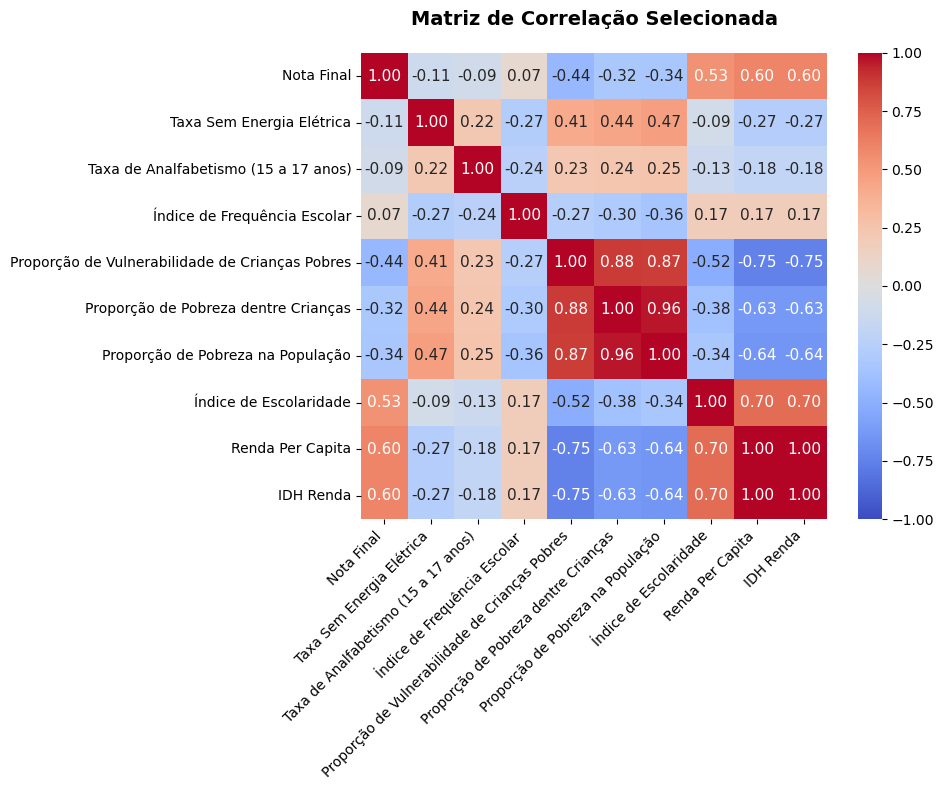

In [13]:
# 1. Define as colunas originais que aparecerão na matriz
colunas_selecionadas = ['nota_final', 'taxa_sem_energia_eletrica', 'taxa_analfabetismo_15_a_17', 'indice_frequencia_escolar', 'prop_vulner_pobreza_criancas', 'prop_pobreza_criancas', 'prop_pobreza', 'indice_escolaridade', 'renda_pc', 'idhm_r']

# 2. Define um dicionário para mapear o nome original para um nome novo mais amigável
novas_labels = {
    'nota_final': 'Nota Final',
    'taxa_sem_energia_eletrica': 'Taxa Sem Energia Elétrica',
    'taxa_analfabetismo_15_a_17': 'Taxa de Analfabetismo (15 a 17 anos)',
    'indice_frequencia_escolar': 'Índice de Frequência Escolar',
    'prop_vulner_pobreza_criancas': 'Proporção de Vulnerabilidade de Crianças Pobres',
    'prop_pobreza_criancas': 'Proporção de Pobreza dentre Crianças',
    'prop_pobreza': 'Proporção de Pobreza na População',
    'indice_escolaridade': 'Índice de Escolaridade',
    'renda_pc': 'Renda Per Capita',
    'idhm_r': 'IDH Renda',
}

# Filtra o DataFrame e renomeia as colunas temporariamente para o gráfico
df_filtrado = df_final[colunas_selecionadas].rename(columns=novas_labels)

# Calcula a matriz de correlação de spearman completa apenas com os dados filtrados
matriz_corr = df_filtrado.corr(method='spearman') 

# 1. Ajusta a área do gráfico de acordo com o número de colunas filtradas
plt.figure(figsize=(10, 8)) 

# Gera o mapa de calor
ax = sns.heatmap(matriz_corr, 
                 annot=True,        
                 cmap='coolwarm',   
                 vmin=-1, vmax=1,   
                 center=0,          
                 fmt='.2f',         
                 square=True,
                 annot_kws={"size": 11}) # Aumentei um pouco a fonte já que há menos quadrados

# 2. Inclina as labels do eixo X em 45 graus e alinha à direita
plt.xticks(rotation=45, ha='right')

# Garante que as labels do eixo Y fiquem 100% na horizontal
plt.yticks(rotation=0)

plt.title('Matriz de Correlação Selecionada', pad=20, fontsize=14, weight='bold')

# O tight_layout evita que os textos inclinados sejam cortados nas bordas da imagem
plt.tight_layout()
plt.show()

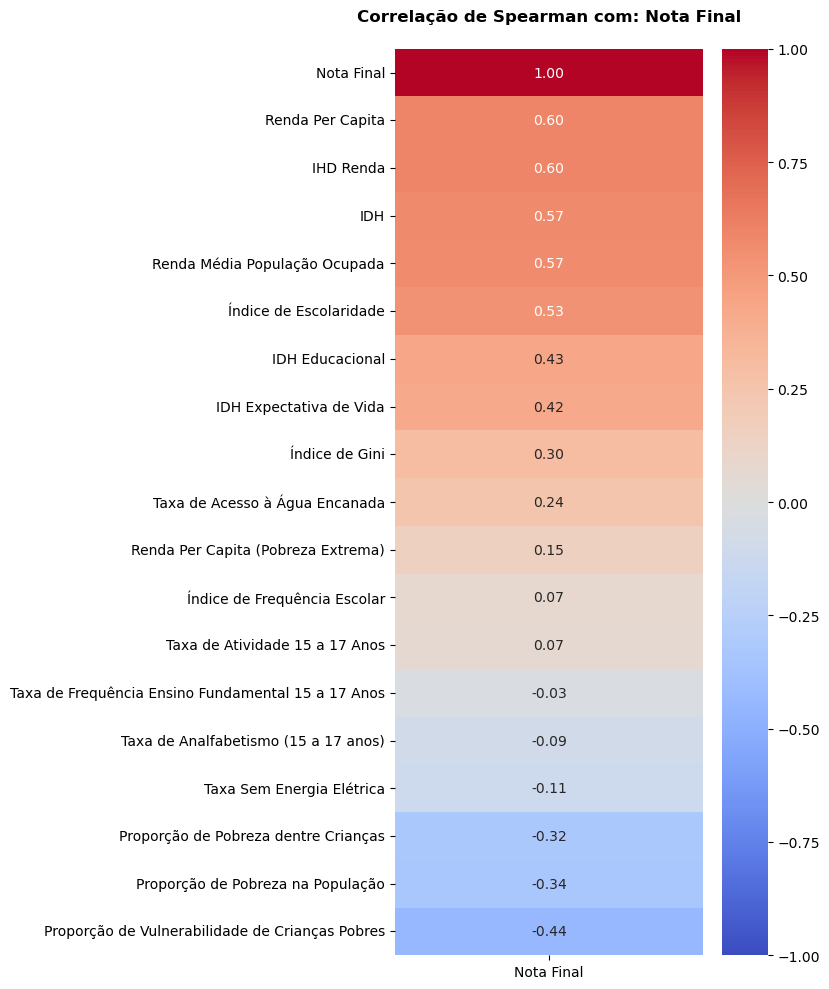

In [14]:
# Aqui renomeamos o nome das colunas do df
novas_labels = {
    'nota_final': 'Nota Final',
    'taxa_sem_energia_eletrica': 'Taxa Sem Energia Elétrica',
    'taxa_analfabetismo_15_a_17': 'Taxa de Analfabetismo (15 a 17 anos)',
    'indice_frequencia_escolar': 'Índice de Frequência Escolar',
    'prop_vulner_pobreza_criancas': 'Proporção de Vulnerabilidade de Crianças Pobres',
    'prop_pobreza_criancas': 'Proporção de Pobreza dentre Crianças',
    'prop_pobreza': 'Proporção de Pobreza na População',
    'indice_escolaridade': 'Índice de Escolaridade',
    'renda_pc': 'Renda Per Capita',
    'idhm_r': 'IHD Renda',
    'idhm': 'IDH',
    'idhm_e': 'IDH Educacional',
    'idhm_l': 'IDH Expectativa de Vida',
    'indice_gini': 'Índice de Gini',
    'taxa_agua_encanada': 'Taxa de Acesso à Água Encanada',
    'renda_pc_pobreza_extrema': 'Renda Per Capita (Pobreza Extrema)',
    'taxa_atividade_15_17': 'Taxa de Atividade 15 a 17 Anos',
    'taxa_freq_fundamental_15_17': 'Taxa de Frequência Ensino Fundamental 15 a 17 Anos',
    'idhm': 'IDH',
    'renda_media_ocupados': 'Renda Média População Ocupada'
}

# Define qual é a sua label alvo já com o novo nome para o filtro do gráfico
label_alvo_renomeada = novas_labels.get('nota_final', 'nota_final')

# Cria uma cópia temporária renomeando as colunas
df_renomeado = df_final.rename(columns=novas_labels)

# 1. Calcula a correlação de SPEARMAN e recortar apenas a coluna de interesse
# usando dois colchetes mantém o formato de DataFrame (matriz)
correlacoes = df_renomeado.corr(method='spearman')[[label_alvo_renomeada]]

# 2. Ordena os valores para facilitar a visualização visual (do mais positivo ao mais negativo)
correlacoes = correlacoes.sort_values(by=label_alvo_renomeada, ascending=False)

# 3. Configura e plota o mapa de calor
plt.figure(figsize=(8, 10)) # Ajuste a altura (10) dependendo do número de colunas
sns.heatmap(correlacoes, 
            annot=True,       # Mostra os números dentro das células
            cmap='coolwarm',  # Esquema de cores intuitivo (vermelho = +, azul = -)
            vmin=-1, vmax=1,  # Trava a escala de correlação entre -1 e 1
            fmt='.2f')        # Arredonda para duas casas decimais

plt.title(f'Correlação de Spearman com: {label_alvo_renomeada}', pad=20, weight='bold')
plt.tight_layout()
plt.show()

## 3.2 Gráficos de dispersão

Embora os coeficientes numéricos sintetizem a força das associações, a estatística descritiva demanda a visualização da distribuição real dos dados. Sendo assim, elaboraram-se gráficos de dispersão para as variáveis de maior destaque nos rankings anteriores. O mapeamento visual permite avaliar a dispersão real das notas dos 645 municípios de São Paulo, identificar a presença de possíveis outliers (municípios fora da curva) e verificar se a relação observada desenha um comportamento linear ou de retornos marginais decrescentes.

### Correlação positiva

In [15]:
# Olhemos agora para as correlações de spearman com resultados positivos, tirando o ''abs()'' e colocando-as em ordem descrescente
spearman = df_final.corr(method='spearman')[variavel_de_notas]
positivas_spearman = spearman.drop(variavel_de_notas).sort_values(ascending=False).head(10)
print(positivas_spearman)

renda_pc                    0.598841
idhm_r                      0.598327
idhm                        0.573366
renda_media_ocupados        0.567323
indice_escolaridade         0.533906
idhm_e                      0.433525
idhm_l                      0.419872
indice_gini                 0.298027
taxa_agua_encanada          0.244081
renda_pc_pobreza_extrema    0.153115
Name: nota_final, dtype: float64


### Gráficos de dispersão dos dados das 3 maiores correlações positivas com a nota final

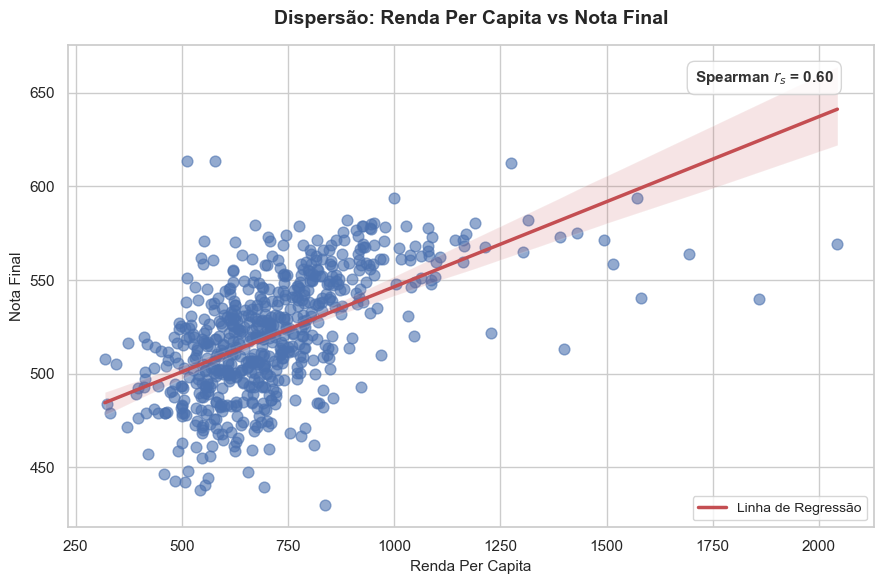

In [16]:
variavel_y = 'nota_final'
variavel_x = 'renda_pc'
nome_y = 'Nota Final'
nome_x = 'Renda Per Capita'

# 1. Calcula a correlação de Pearson dinamicamente para essas duas variáveis
valor_spearman = df_final[variavel_x].corr(df_final[variavel_y], method = 'spearman')

# Configura o estilo visual limpo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 6))

# 2. Gera a dispersão com a linha de tendência e adiciona o label para a legenda
sns.regplot(data=df_final,              
            x=variavel_x, 
            y=variavel_y,
            color="#4c72b0",               
            scatter_kws={'alpha':0.6, 's':60, 'label': 'Dados Observados'}, 
            line_kws={'color':'#c44e52', 'lw':2.5, 'label': 'Linha de Regressão'}) 

# 3. Adiciona a caixa de texto com o valor de Spearman no canto superior direito
# transform=ax.transAxes faz com que as coordenadas (0.05 a 0.95) sejam relativas aos eixos do gráfico
ax = plt.gca()
texto_spearman = f'Spearman $r_s$ = {valor_spearman:.2f}'
plt.text(0.95, 0.95, texto_spearman, 
         transform=ax.transAxes, 
         fontsize=11, 
         weight='bold',
         color='#333333',
         verticalalignment='top', 
         horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='#cccccc'))

# Títulos e rótulos
plt.title(f'Dispersão: {nome_x} vs {nome_y}', fontsize=14, pad=15, weight='bold')
plt.xlabel(nome_x, fontsize=11)
plt.ylabel(nome_y, fontsize=11)

# 4. Ativa a legenda na tela
plt.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

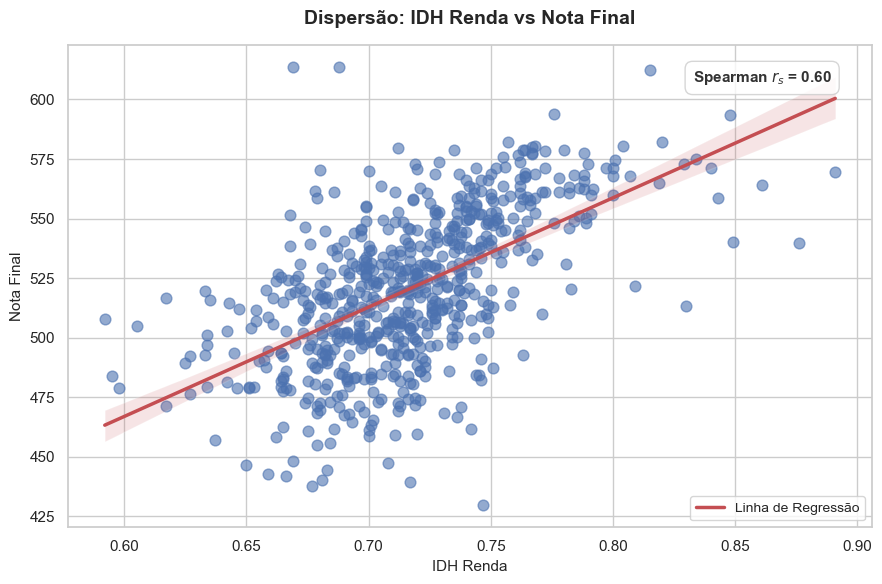

In [17]:
variavel_y = 'nota_final'
variavel_x = 'idhm_r'
nome_y = 'Nota Final'
nome_x = 'IDH Renda'

# 1. Calcula a correlação de Pearson dinamicamente para essas duas variáveis
valor_spearman = df_final[variavel_x].corr(df_final[variavel_y], method = 'spearman')

# Configura o estilo visual limpo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 6))

# 2. Gera a dispersão com a linha de tendência e adiciona o label para a legenda
sns.regplot(data=df_final,              
            x=variavel_x, 
            y=variavel_y,
            color="#4c72b0",               
            scatter_kws={'alpha':0.6, 's':60, 'label': 'Dados Observados'}, 
            line_kws={'color':'#c44e52', 'lw':2.5, 'label': 'Linha de Regressão'}) 

# 3. Adiciona a caixa de texto com o valor de Spearman no canto superior direito
# transform=ax.transAxes faz com que as coordenadas (0.05 a 0.95) sejam relativas aos eixos do gráfico
ax = plt.gca()
texto_spearman = f'Spearman $r_s$ = {valor_spearman:.2f}'
plt.text(0.95, 0.95, texto_spearman, 
         transform=ax.transAxes, 
         fontsize=11, 
         weight='bold',
         color='#333333',
         verticalalignment='top', 
         horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='#cccccc'))

# Títulos e rótulos
plt.title(f'Dispersão: {nome_x} vs {nome_y}', fontsize=14, pad=15, weight='bold')
plt.xlabel(nome_x, fontsize=11)
plt.ylabel(nome_y, fontsize=11)

# 4. Ativa a legenda na tela
plt.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

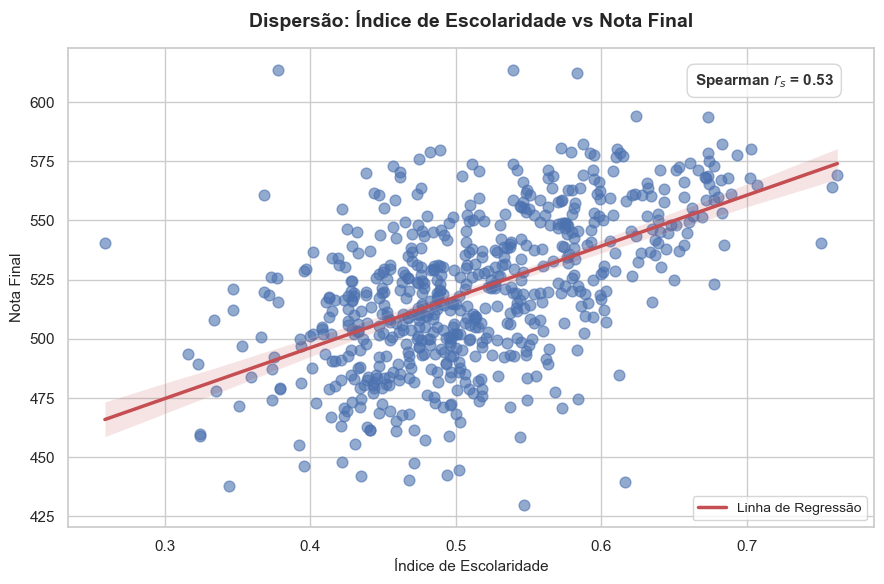

In [18]:
variavel_y = 'nota_final'
variavel_x = 'indice_escolaridade'
nome_y = 'Nota Final'
nome_x = 'Índice de Escolaridade'

# 1. Calcula a correlação de Pearson dinamicamente para essas duas variáveis
valor_spearman = df_final[variavel_x].corr(df_final[variavel_y], method = 'spearman')

# Configura o estilo visual limpo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 6))

# 2. Gera a dispersão com a linha de tendência e adiciona o label para a legenda
sns.regplot(data=df_final,              
            x=variavel_x, 
            y=variavel_y,
            color="#4c72b0",               
            scatter_kws={'alpha':0.6, 's':60, 'label': 'Dados Observados'}, 
            line_kws={'color':'#c44e52', 'lw':2.5, 'label': 'Linha de Regressão'}) 

# 3. Adiciona a caixa de texto com o valor de Spearman no canto superior direito
# transform=ax.transAxes faz com que as coordenadas (0.05 a 0.95) sejam relativas aos eixos do gráfico
ax = plt.gca()
texto_spearman = f'Spearman $r_s$ = {valor_spearman:.2f}'
plt.text(0.95, 0.95, texto_spearman, 
         transform=ax.transAxes, 
         fontsize=11, 
         weight='bold',
         color='#333333',
         verticalalignment='top', 
         horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='#cccccc'))

# Títulos e rótulos
plt.title(f'Dispersão: {nome_x} vs {nome_y}', fontsize=14, pad=15, weight='bold')
plt.xlabel(nome_x, fontsize=11)
plt.ylabel(nome_y, fontsize=11)

# 4. Ativa a legenda na tela
plt.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

### Correlação fracas

In [19]:
# Olhemos agora para as correlações de spearman com os menores valores, colocando-as em ordem crescente
spearman = df_final.corr(method='spearman')[variavel_de_notas].abs()
menores_spearman = spearman.drop(variavel_de_notas).sort_values(ascending=True).head(10)
print(menores_spearman)

taxa_freq_fundamental_15_17    0.027713
taxa_atividade_15_17           0.065885
indice_frequencia_escolar      0.070811
taxa_analfabetismo_15_a_17     0.092099
taxa_sem_energia_eletrica      0.111663
renda_pc_pobreza_extrema       0.153115
taxa_agua_encanada             0.244081
indice_gini                    0.298027
prop_pobreza_criancas          0.324932
prop_pobreza                   0.338868
Name: nota_final, dtype: float64


### Gráficos de dispersão dos dados das 4 menores correlações com a nota final

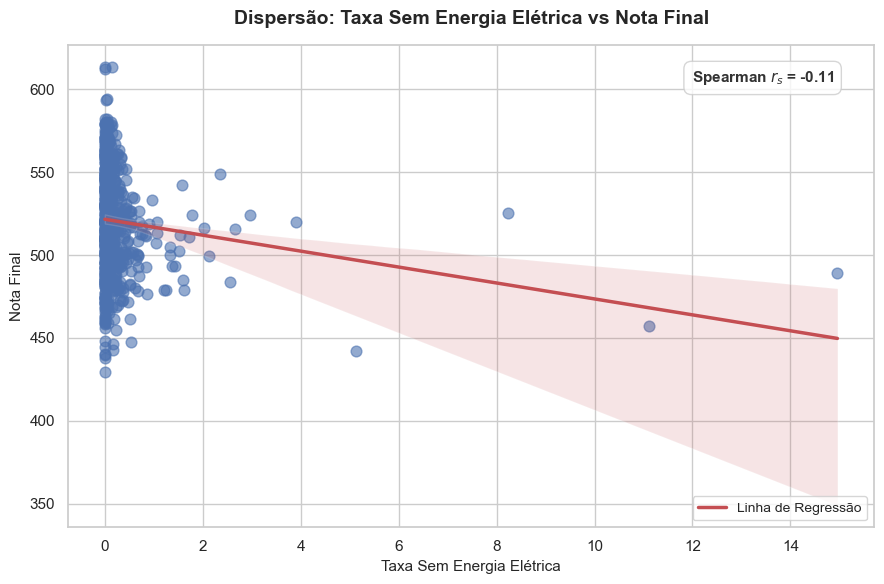

In [20]:
variavel_y = 'nota_final'
variavel_x = 'taxa_sem_energia_eletrica'
nome_y = 'Nota Final'
nome_x = 'Taxa Sem Energia Elétrica'

# 1. Calcula a correlação de Pearson dinamicamente para essas duas variáveis
valor_spearman = df_final[variavel_x].corr(df_final[variavel_y], method = 'spearman')

# Configura o estilo visual limpo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 6))

# 2. Gera a dispersão com a linha de tendência e adiciona o label para a legenda
sns.regplot(data=df_final,              
            x=variavel_x, 
            y=variavel_y,
            color="#4c72b0",               
            scatter_kws={'alpha':0.6, 's':60, 'label': 'Dados Observados'}, 
            line_kws={'color':'#c44e52', 'lw':2.5, 'label': 'Linha de Regressão'}) 

# 3. Adiciona a caixa de texto com o valor de Spearman no canto superior direito
# transform=ax.transAxes faz com que as coordenadas (0.05 a 0.95) sejam relativas aos eixos do gráfico
ax = plt.gca()
texto_spearman = f'Spearman $r_s$ = {valor_spearman:.2f}'
plt.text(0.95, 0.95, texto_spearman, 
         transform=ax.transAxes, 
         fontsize=11, 
         weight='bold',
         color='#333333',
         verticalalignment='top', 
         horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='#cccccc'))

# Títulos e rótulos
plt.title(f'Dispersão: {nome_x} vs {nome_y}', fontsize=14, pad=15, weight='bold')
plt.xlabel(nome_x, fontsize=11)
plt.ylabel(nome_y, fontsize=11)

# 4. Ativa a legenda na tela
plt.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

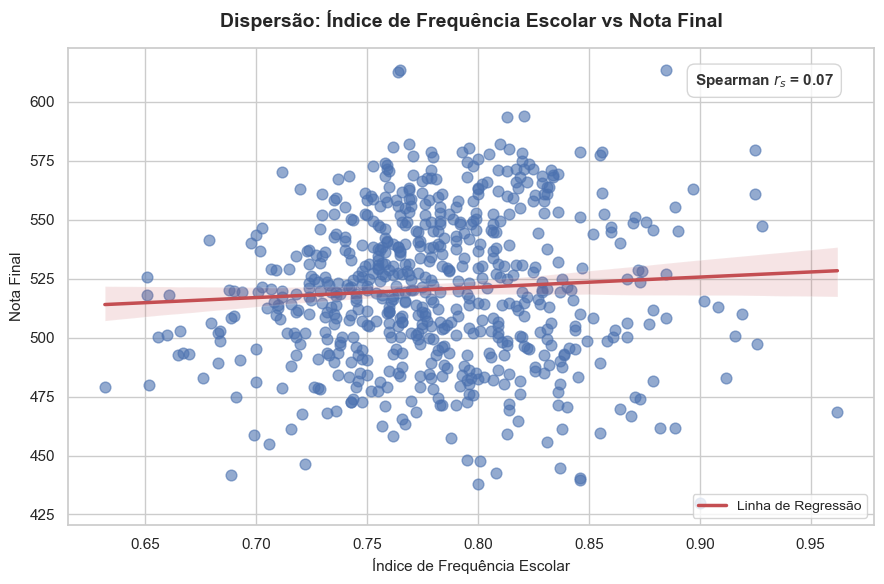

In [21]:
variavel_y = 'nota_final'
variavel_x = 'indice_frequencia_escolar'
nome_y = 'Nota Final'
nome_x = 'Índice de Frequência Escolar'

# 1. Calcula a correlação de Pearson dinamicamente para essas duas variáveis
valor_spearman = df_final[variavel_x].corr(df_final[variavel_y], method = 'spearman')

# Configura o estilo visual limpo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 6))

# 2. Gera a dispersão com a linha de tendência e adiciona o label para a legenda
sns.regplot(data=df_final,              
            x=variavel_x, 
            y=variavel_y,
            color="#4c72b0",               
            scatter_kws={'alpha':0.6, 's':60, 'label': 'Dados Observados'}, 
            line_kws={'color':'#c44e52', 'lw':2.5, 'label': 'Linha de Regressão'}) 

# 3. Adiciona a caixa de texto com o valor de Spearman no canto superior direito
# transform=ax.transAxes faz com que as coordenadas (0.05 a 0.95) sejam relativas aos eixos do gráfico
ax = plt.gca()
texto_spearman = f'Spearman $r_s$ = {valor_spearman:.2f}'
plt.text(0.95, 0.95, texto_spearman, 
         transform=ax.transAxes, 
         fontsize=11, 
         weight='bold',
         color='#333333',
         verticalalignment='top', 
         horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='#cccccc'))

# Títulos e rótulos
plt.title(f'Dispersão: {nome_x} vs {nome_y}', fontsize=14, pad=15, weight='bold')
plt.xlabel(nome_x, fontsize=11)
plt.ylabel(nome_y, fontsize=11)

# 4. Ativa a legenda na tela
plt.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

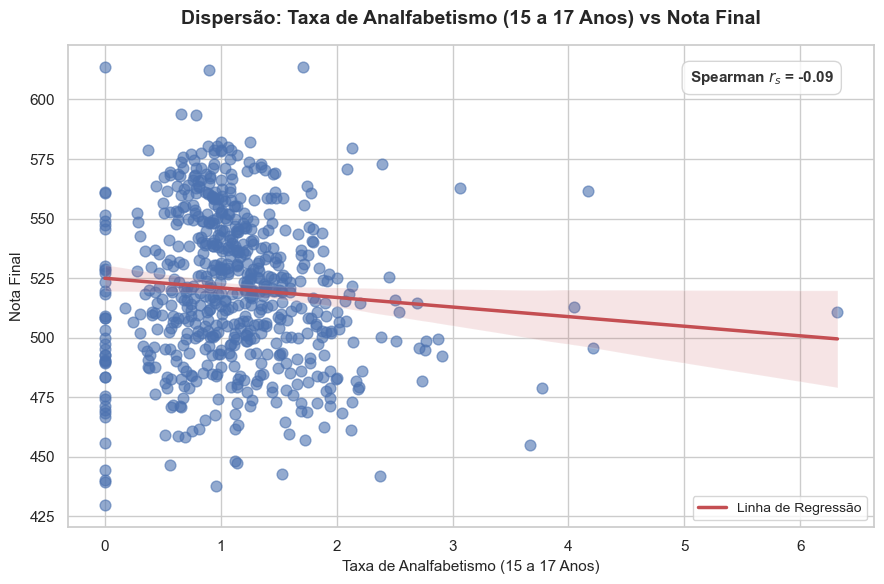

In [22]:
variavel_y = 'nota_final'
variavel_x = 'taxa_analfabetismo_15_a_17'
nome_y = 'Nota Final'
nome_x = 'Taxa de Analfabetismo (15 a 17 Anos)'

# 1. Calcula a correlação de Pearson dinamicamente para essas duas variáveis
valor_spearman = df_final[variavel_x].corr(df_final[variavel_y], method = 'spearman')

# Configura o estilo visual limpo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 6))

# 2. Gera a dispersão com a linha de tendência e adiciona o label para a legenda
sns.regplot(data=df_final,              
            x=variavel_x, 
            y=variavel_y,
            color="#4c72b0",               
            scatter_kws={'alpha':0.6, 's':60, 'label': 'Dados Observados'}, 
            line_kws={'color':'#c44e52', 'lw':2.5, 'label': 'Linha de Regressão'}) 

# 3. Adiciona a caixa de texto com o valor de Spearman no canto superior direito
# transform=ax.transAxes faz com que as coordenadas (0.05 a 0.95) sejam relativas aos eixos do gráfico
ax = plt.gca()
texto_spearman = f'Spearman $r_s$ = {valor_spearman:.2f}'
plt.text(0.95, 0.95, texto_spearman, 
         transform=ax.transAxes, 
         fontsize=11, 
         weight='bold',
         color='#333333',
         verticalalignment='top', 
         horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='#cccccc'))

# Títulos e rótulos
plt.title(f'Dispersão: {nome_x} vs {nome_y}', fontsize=14, pad=15, weight='bold')
plt.xlabel(nome_x, fontsize=11)
plt.ylabel(nome_y, fontsize=11)

# 4. Ativa a legenda na tela
plt.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

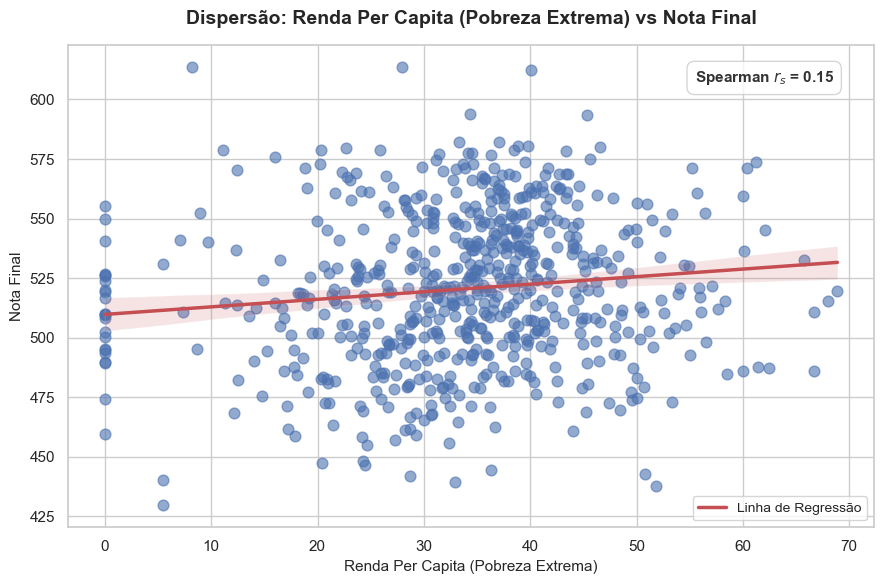

In [23]:
variavel_y = 'nota_final'
variavel_x = 'renda_pc_pobreza_extrema'
nome_y = 'Nota Final'
nome_x = 'Renda Per Capita (Pobreza Extrema)'

# 1. Calcula a correlação de Pearson dinamicamente para essas duas variáveis
valor_spearman = df_final[variavel_x].corr(df_final[variavel_y], method = 'spearman')

# Configura o estilo visual limpo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 6))

# 2. Gera a dispersão com a linha de tendência e adiciona o label para a legenda
sns.regplot(data=df_final,              
            x=variavel_x, 
            y=variavel_y,
            color="#4c72b0",               
            scatter_kws={'alpha':0.6, 's':60, 'label': 'Dados Observados'}, 
            line_kws={'color':'#c44e52', 'lw':2.5, 'label': 'Linha de Regressão'}) 

# 3. Adiciona a caixa de texto com o valor de Spearman no canto superior direito
# transform=ax.transAxes faz com que as coordenadas (0.05 a 0.95) sejam relativas aos eixos do gráfico
ax = plt.gca()
texto_spearman = f'Spearman $r_s$ = {valor_spearman:.2f}'
plt.text(0.95, 0.95, texto_spearman, 
         transform=ax.transAxes, 
         fontsize=11, 
         weight='bold',
         color='#333333',
         verticalalignment='top', 
         horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='#cccccc'))

# Títulos e rótulos
plt.title(f'Dispersão: {nome_x} vs {nome_y}', fontsize=14, pad=15, weight='bold')
plt.xlabel(nome_x, fontsize=11)
plt.ylabel(nome_y, fontsize=11)

# 4. Ativa a legenda na tela
plt.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

### Correlação negativa

In [24]:
# Olhemos agora para as correlações de spearman com resultados negativos, tirando o ''abs()'' e colocando-as em ordem crescente
spearman = df_final.corr(method='spearman')[variavel_de_notas]
negativas_spearman = spearman.drop(variavel_de_notas).sort_values(ascending=True).head(10)
print(negativas_spearman)

prop_vulner_pobreza_criancas   -0.442633
prop_pobreza                   -0.338868
prop_pobreza_criancas          -0.324932
taxa_sem_energia_eletrica      -0.111663
taxa_analfabetismo_15_a_17     -0.092099
taxa_freq_fundamental_15_17    -0.027713
taxa_atividade_15_17            0.065885
indice_frequencia_escolar       0.070811
renda_pc_pobreza_extrema        0.153115
taxa_agua_encanada              0.244081
Name: nota_final, dtype: float64


### Gráficos de dispersão dos dados das 3 maiores correlações negativas com a nota final

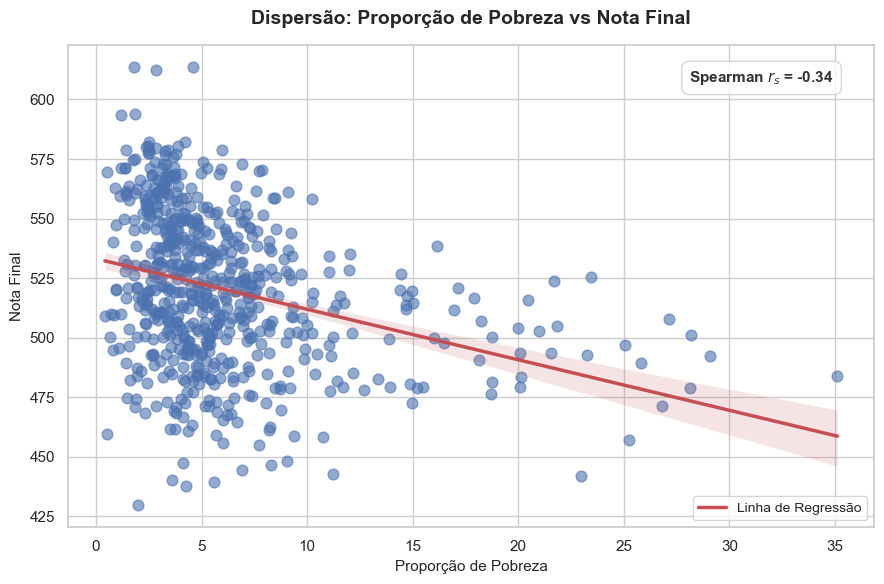

In [25]:
variavel_y = 'nota_final'
variavel_x = 'prop_pobreza'
nome_y = 'Nota Final'
nome_x = 'Proporção de Pobreza'

# 1. Calcula a correlação de Pearson dinamicamente para essas duas variáveis
valor_spearman = df_final[variavel_x].corr(df_final[variavel_y], method = 'spearman')

# Configura o estilo visual limpo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 6))

# 2. Gera a dispersão com a linha de tendência e adiciona o label para a legenda
sns.regplot(data=df_final,              
            x=variavel_x, 
            y=variavel_y,
            color="#4c72b0",               
            scatter_kws={'alpha':0.6, 's':60, 'label': 'Dados Observados'}, 
            line_kws={'color':'#c44e52', 'lw':2.5, 'label': 'Linha de Regressão'}) 

# 3. Adiciona a caixa de texto com o valor de Spearman no canto superior direito
# transform=ax.transAxes faz com que as coordenadas (0.05 a 0.95) sejam relativas aos eixos do gráfico
ax = plt.gca()
texto_spearman = f'Spearman $r_s$ = {valor_spearman:.2f}'
plt.text(0.95, 0.95, texto_spearman, 
         transform=ax.transAxes, 
         fontsize=11, 
         weight='bold',
         color='#333333',
         verticalalignment='top', 
         horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='#cccccc'))

# Títulos e rótulos
plt.title(f'Dispersão: {nome_x} vs {nome_y}', fontsize=14, pad=15, weight='bold')
plt.xlabel(nome_x, fontsize=11)
plt.ylabel(nome_y, fontsize=11)

# 4. Ativa a legenda na tela
plt.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

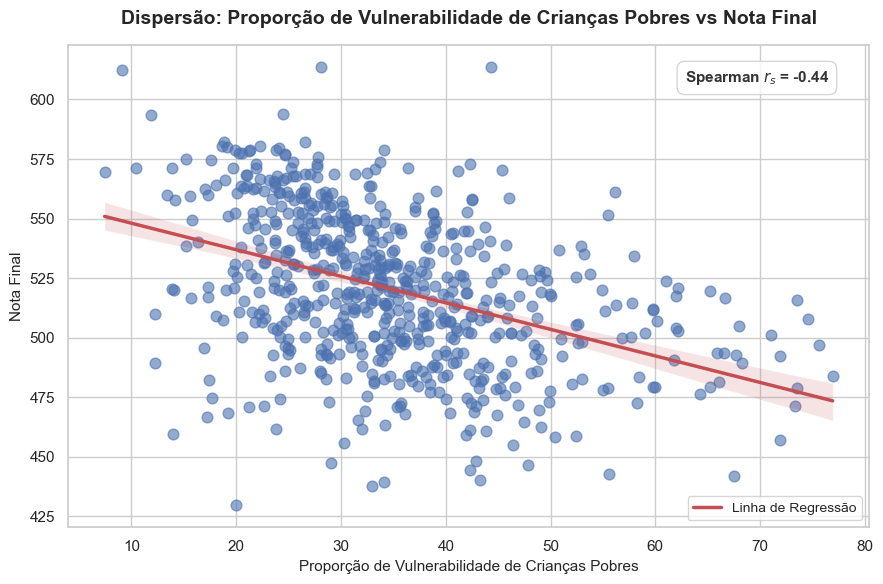

In [26]:
variavel_y = 'nota_final'
variavel_x = 'prop_vulner_pobreza_criancas'
nome_y = 'Nota Final'
nome_x = 'Proporção de Vulnerabilidade de Crianças Pobres'

# 1. Calcula a correlação de Pearson dinamicamente para essas duas variáveis
valor_spearman = df_final[variavel_x].corr(df_final[variavel_y], method = 'spearman')

# Configura o estilo visual limpo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 6))

# 2. Gera a dispersão com a linha de tendência e adiciona o label para a legenda
sns.regplot(data=df_final,              
            x=variavel_x, 
            y=variavel_y,
            color="#4c72b0",               
            scatter_kws={'alpha':0.6, 's':60, 'label': 'Dados Observados'}, 
            line_kws={'color':'#c44e52', 'lw':2.5, 'label': 'Linha de Regressão'}) 

# 3. Adiciona a caixa de texto com o valor de Spearman no canto superior direito
# transform=ax.transAxes faz com que as coordenadas (0.05 a 0.95) sejam relativas aos eixos do gráfico
ax = plt.gca()
texto_spearman = f'Spearman $r_s$ = {valor_spearman:.2f}'
plt.text(0.95, 0.95, texto_spearman, 
         transform=ax.transAxes, 
         fontsize=11, 
         weight='bold',
         color='#333333',
         verticalalignment='top', 
         horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='#cccccc'))

# Títulos e rótulos
plt.title(f'Dispersão: {nome_x} vs {nome_y}', fontsize=14, pad=15, weight='bold')
plt.xlabel(nome_x, fontsize=11)
plt.ylabel(nome_y, fontsize=11)

# 4. Ativa a legenda na tela
plt.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

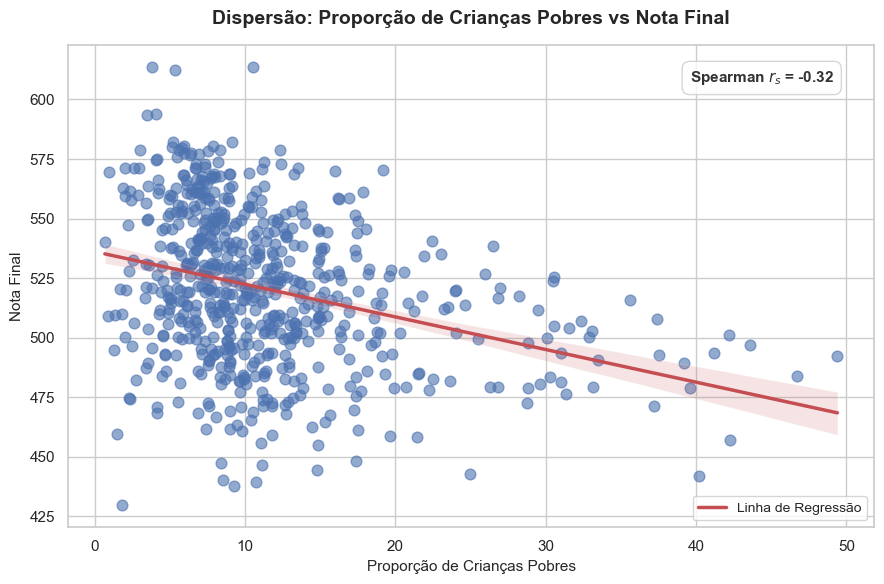

In [27]:
variavel_y = 'nota_final'
variavel_x = 'prop_pobreza_criancas'
nome_y = 'Nota Final'
nome_x = 'Proporção de Crianças Pobres'

# 1. Calcula a correlação de Pearson dinamicamente para essas duas variáveis
valor_spearman = df_final[variavel_x].corr(df_final[variavel_y], method = 'spearman')

# Configura o estilo visual limpo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 6))

# 2. Gera a dispersão com a linha de tendência e adiciona o label para a legenda
sns.regplot(data=df_final,              
            x=variavel_x, 
            y=variavel_y,
            color="#4c72b0",               
            scatter_kws={'alpha':0.6, 's':60, 'label': 'Dados Observados'}, 
            line_kws={'color':'#c44e52', 'lw':2.5, 'label': 'Linha de Regressão'}) 

# 3. Adiciona a caixa de texto com o valor de Spearman no canto superior direito
# transform=ax.transAxes faz com que as coordenadas (0.05 a 0.95) sejam relativas aos eixos do gráfico
ax = plt.gca()
texto_spearman = f'Spearman $r_s$ = {valor_spearman:.2f}'
plt.text(0.95, 0.95, texto_spearman, 
         transform=ax.transAxes, 
         fontsize=11, 
         weight='bold',
         color='#333333',
         verticalalignment='top', 
         horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='#cccccc'))

# Títulos e rótulos
plt.title(f'Dispersão: {nome_x} vs {nome_y}', fontsize=14, pad=15, weight='bold')
plt.xlabel(nome_x, fontsize=11)
plt.ylabel(nome_y, fontsize=11)

# 4. Ativa a legenda na tela
plt.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

## 3.3 Mapas de calor

A representação espacial dos indicadores permite identificar padrões regionais de desigualdade a partir da utilização da biblioteca geopandas, verificando se municípios com melhores condições socioeconômicas concentram-se nas mesmas regiões com maiores desempenhos no ENEM e vice-versa.

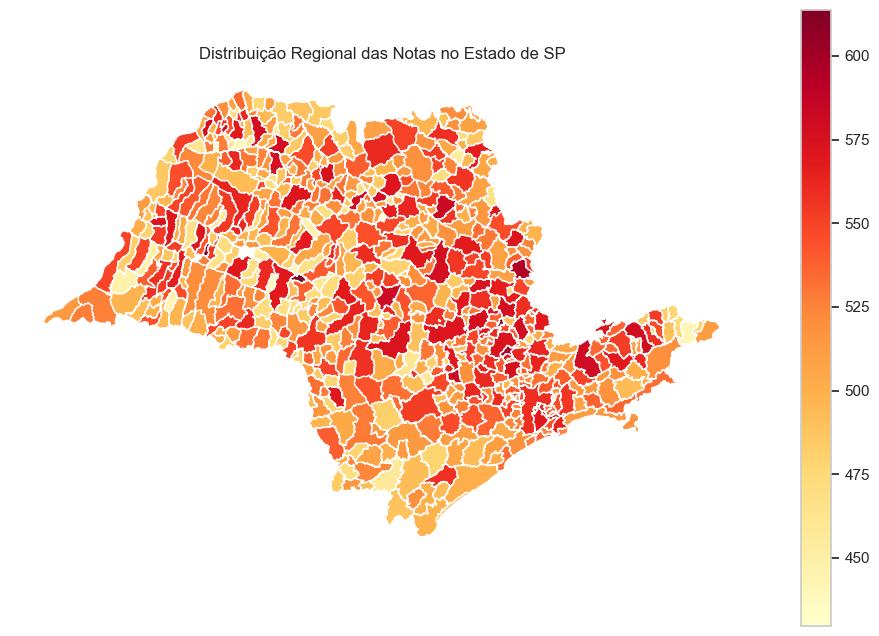

In [28]:
# Carregar o mapa de municípios de SP que baixou
mapa_sp = gpd.read_file('data/shp/SP_Municipios_2024.shp')

# Garantir que o ID do município é string para o cruzamento
mapa_sp['CD_MUN'] = mapa_sp['CD_MUN'].astype(str)
df_final_reset = df_final.reset_index()
df_final_reset['id_municipio'] = df_final_reset['id_municipio'].astype(str)

# Unir os dados alfanuméricos com o mapa geométrico
mapa_final = mapa_sp.merge(df_final_reset, left_on='CD_MUN', right_on='id_municipio')
# Plotar o mapa de calor da nota final
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
mapa_final.plot(column='nota_final', cmap='YlOrRd', legend=True, ax=ax)
plt.title('Distribuição Regional das Notas no Estado de SP')
plt.axis('off')
plt.show()

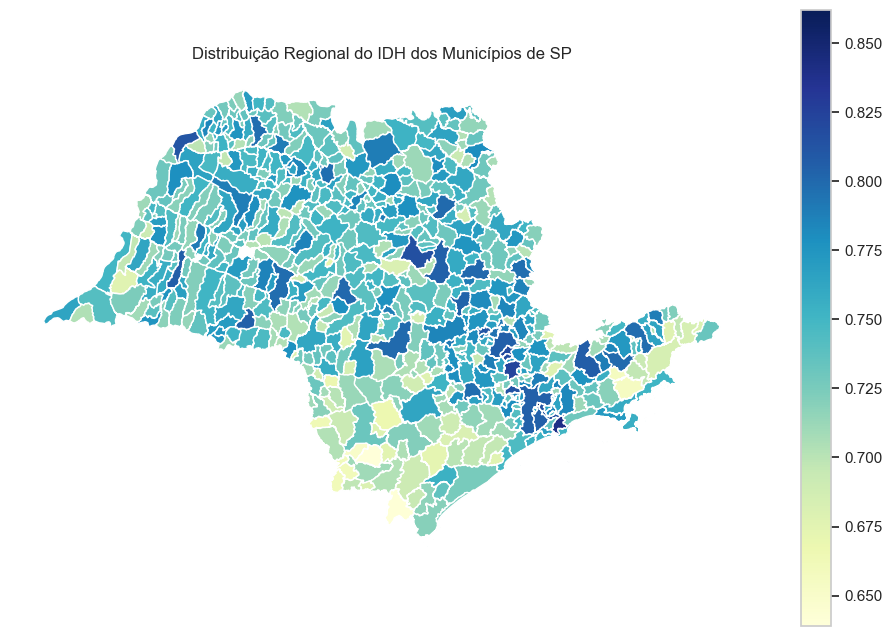

In [29]:
# Criar o mapa de calor para idh_municipio
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
mapa_final.plot(column='idhm', cmap='YlGnBu', legend=True, ax=ax)
plt.title('Distribuição Regional do IDH dos Municípios de SP')
plt.axis('off')
plt.show()


Como é perceptível a partir de uma comparação com os dois gráficos, tanto a distribuição das notas do ENEM pelo estado quanto a nível do IDH são bem pulverizados pelo território, exceto por algumas regiões que evidentemente possuem uma tendência mais alta ou mais baixa em ambos, como por exemplo uma concentração positiva de notas e IDH na região metropolitana da capital e uma negativa no sudoeste. 

# 4. Conclusão

Considerações finais e sugestões de passos futuros para enriquecimento da análise
- Evidências foram favoráveis ou contrárias à hipótese
- Sugerir aprofundamentos


Em suma,  partindo partindo para a conclusão da análise, confirmou-se que o desempenho dos municípios paulistas no ENEM não ocorre de forma isolada, sendo reflexo do contexto socioeconômico complexo. Ao investigar a relação entre indicadores de desenvolvimento humano, infraestrutura e as notas médias no exame, foi possível validar a premissa de que a desigualdade educacional em São Paulo possui raízes estruturais profundas.

O embasamento teórico no Coleman Report, de 1966, mostrou-se acertado para o contexto paulista: a trajetória educacional dos estudantes é, em grande parte, condicionada por variáveis que extrapolam o ambiente escolar. Os dados evidenciaram que municípios com melhores índices de desenvolvimento humano (IDHM), renda per capita elevada e acesso robusto a serviços básicos tendem a apresentar notas significativamente superiores, enquanto regiões marcadas por vulnerabilidade social (caracterizadas por menores indicadores de escolaridade e renda) enfrentam desafios contínuos para elevar o desempenho de seus estudantes no exame.
>$$Y_{ENEM} = \beta_0 + \beta_1(Infra) + \beta_2(IDHM) + \beta_3(Educ\_Pais) + \varepsilon$$

Dessa forma, o trabalho conclui que políticas públicas focadas exclusivamente na melhoria da infraestrutura escolar ou em intervenções pedagógicas limitadas podem ter sua eficácia reduzida se não forem acompanhadas de estratégias multisetoriais. Para mitigar as disparidades observadas, é importante, e ao mesmo tempo necessário, que o Estado atue na redução das desigualdades de base (renda, saneamento e escolaridade da população adulta), visto que estas são, em última análise, os principais preditores do sucesso acadêmico.

Como sugestão para trabalhos futuros, é recomendado aprofundar a investigação incorporando variáveis de investimento específico em educação por município e a análise da distribuição de professores capacitados. O mapeamento geográfico das notas, combinado com a análise de regressão, oferece um diagnóstico claro: o ENEM é, também, um espelho das diferenças socioeconômicas territoriais de São Paulo, exigindo um olhar de política pública que seja, simultaneamente, educacional e social.